In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Lección 3 — Inferencia en Regresión Lineal Simple
### Aplicación de métodos multivariados en ciencia de datos

Este notebook reproduce **a mano** (sin `statsmodels`) todas las operaciones de la Lección 3:

| Sección | Contenido |
|---|---|
| 1 | Datos y setup |
| 2 | Modelo lineal por MCO / fórmula cerrada |
| 3 | Tabla ANOVA (descomposición de la varianza) |
| 4 | Prueba F — significancia global |
| 5 | Prueba t — significancia individual de $\beta_0$ y $\beta_1$ |
| 6 | Verificación de la relación $F = t^2$ |
| 7 | Intervalos de confianza para los coeficientes |
| 8 | Tabla de IC de la media e IP (intervalo de predicción) |
| 9 | Visualización de las bandas |
| 10 | Resumen |

**Modelo:** $\text{Nota} = \beta_0 + \beta_1 \cdot \text{Horas} + \varepsilon$


---
## 1. Datos y setup

Aquí solo cargamos las librerías y construimos el DataFrame del ejemplo de la presentación
(10 estudiantes: horas de estudio vs calificación). Todo lo demás sale de estos datos.


In [2]:
# Librerías base: numpy para álgebra, pandas para tablas,
# scipy.stats para las distribuciones t y F (valores críticos y p-valores),
# matplotlib para la gráfica final de la sección 9.
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# Que los floats se impriman a 4 decimales, igual que en las diapositivas.
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
np.set_printoptions(precision=4, suppress=True)

In [3]:
# Datos del ejemplo de la Lección 3.
# X = Horas de estudio (variable predictora), Y = Nota (variable respuesta).
datos = pd.DataFrame({
    'Estudiante': range(1, 11),
    'Horas': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Nota':  [3.2, 4.5, 5.0, 6.8, 7.0, 8.5, 9.0, 9.2, 9.8, 10.0]
})

datos

,Estudiante,Horas,Nota
0,1,1,3.2000
1,2,2,4.5000
2,3,3,5.0000
3,4,4,6.8000
4,5,5,7.0000
5,6,6,8.5000
6,7,7,9.0000
7,8,8,9.2000
8,9,9,9.8000
9,10,10,10.0000


In [4]:
# Extraemos los vectores como float para evitar división entera y
# fijamos las constantes del problema que se usan en TODO el notebook.
x = datos['Horas'].to_numpy(dtype=float)   # variable independiente X
y = datos['Nota'].to_numpy(dtype=float)    # variable dependiente Y

n = len(x)     # número de observaciones -> n = 10
p = 1          # número de predictores (regresión simple) -> p = 1
alpha = 0.05   # nivel de significancia para todas las pruebas e intervalos

print(f"n = {n} observaciones, p = {p} predictor, alpha = {alpha}")

n = 10 observaciones, p = 1 predictor, alpha = 0.05


---
## 2. Modelo lineal por MCO (fórmula cerrada)

Mínimos Cuadrados Ordinarios minimiza $\sum (y_i - \hat y_i)^2$. Para regresión simple la solución
tiene **forma cerrada**:

$$\hat\beta_1 = \frac{S_{xy}}{S_{xx}} = \frac{\sum (x_i-\bar x)(y_i-\bar y)}{\sum (x_i-\bar x)^2}
\qquad\qquad
\hat\beta_0 = \bar y - \hat\beta_1 \bar x$$

$S_{xx}$ no es solo un paso intermedio: reaparece en **todos** los errores estándar de las
secciones 5, 7 y 8, así que lo guardamos.


In [5]:
# Medias y sumas de productos cruzados: la materia prima de la fórmula cerrada.
x_bar = x.mean()
y_bar = y.mean()

Sxx = np.sum((x - x_bar) ** 2)              # variabilidad de X (se reusa en todos los SE)
Sxy = np.sum((x - x_bar) * (y - y_bar))     # covariación entre X y Y

print(f"x_barra = {x_bar:.4f}")
print(f"y_barra = {y_bar:.4f}")
print(f"Sxx     = {Sxx:.4f}")
print(f"Sxy     = {Sxy:.4f}")

x_barra = 5.5000
y_barra = 7.3000
Sxx     = 82.5000
Sxy     = 63.7000


In [6]:
# Estimadores MCO por fórmula cerrada.
beta1 = Sxy / Sxx           # pendiente: cuánto sube la nota por cada hora extra
beta0 = y_bar - beta1 * x_bar   # intercepto: nota esperada con 0 horas

# Valores ajustados y residuos: se usan para las sumas de cuadrados de la sección 3.
y_hat = beta0 + beta1 * x
residuos = y - y_hat

print(f"beta0_hat = {beta0:.4f}")
print(f"beta1_hat = {beta1:.4f}")
print(f"\nModelo estimado:  y_hat = {beta0:.4f} + {beta1:.4f} * x")

beta0_hat = 3.0533
beta1_hat = 0.7721

Modelo estimado:  y_hat = 3.0533 + 0.7721 * x


In [7]:
# Verificación por álgebra matricial: beta_hat = (X'X)^(-1) X'y.
# Es el mismo MCO, pero en la forma que se generaliza a regresión múltiple.
# Si ambos métodos coinciden, la fórmula cerrada quedó bien implementada.
X = np.column_stack([np.ones(n), x])        # matriz de diseño con columna de 1's
beta_matricial = np.linalg.inv(X.T @ X) @ X.T @ y

print("Fórmula cerrada :", np.array([beta0, beta1]))
print("Vía matricial   :", beta_matricial)
print("¿Coinciden?     :", np.allclose([beta0, beta1], beta_matricial))

Fórmula cerrada : [3.0533 0.7721]
Vía matricial   : [3.0533 0.7721]
¿Coinciden?     : True


In [8]:
# Tabla observado vs ajustado vs residuo, para ver de dónde saldrá el SSE.
tabla_ajuste = datos.copy()
tabla_ajuste['y_hat']    = y_hat
tabla_ajuste['residuo']  = residuos
tabla_ajuste['residuo2'] = residuos ** 2

tabla_ajuste

,Estudiante,Horas,Nota,y_hat,residuo,residuo2
0,1,1,3.2000,3.8255,-0.6255,0.3912
1,2,2,4.5000,4.5976,-0.0976,0.0095
2,3,3,5.0000,5.3697,-0.3697,0.1367
3,4,4,6.8000,6.1418,0.6582,0.4332
4,5,5,7.0000,6.9139,0.0861,0.0074
5,6,6,8.5000,7.6861,0.8139,0.6625
6,7,7,9.0000,8.4582,0.5418,0.2936
7,8,8,9.2000,9.2303,-0.0303,0.0009
8,9,9,9.8000,10.0024,-0.2024,0.0410
9,10,10,10.0000,10.7745,-0.7745,0.5999


---
## 3. Tabla ANOVA — descomposición de la varianza

La varianza total de $Y$ se parte en dos pedazos:

$$\underbrace{\sum (y_i-\bar y)^2}_{SST} = \underbrace{\sum (\hat y_i-\bar y)^2}_{SSR}
+ \underbrace{\sum (y_i-\hat y_i)^2}_{SSE}$$

| Fuente | SS | df | MS | F |
|---|---|---|---|---|
| Regresión | SSR | $p$ | MSR = SSR/$p$ | MSR/MSE |
| Error | SSE | $n-p-1$ | MSE = SSE/$(n-p-1)$ | |
| Total | SST | $n-1$ | | |

Los grados de libertad también se descomponen: $df_{Total} = df_{Reg} + df_{Error}$, es decir
$9 = 1 + 8$.

> ⚠️ Ojo con la diapositiva 10 de la presentación: dice "9 = 2 + 7 ✓". Es un typo — con $p=1$
> lo correcto es **9 = 1 + 8**, que es justo lo que verifica la celda de abajo.


In [9]:
# Sumas de cuadrados: las tres piezas de la descomposición.
SST = np.sum((y - y_bar) ** 2)      # variabilidad total de Y
SSR = np.sum((y_hat - y_bar) ** 2)  # variabilidad explicada por el modelo
SSE = np.sum((y - y_hat) ** 2)      # variabilidad NO explicada (residual)

print(f"SST = {SST:.4f}")
print(f"SSR = {SSR:.4f}")
print(f"SSE = {SSE:.4f}")

# Verificación de la identidad SST = SSR + SSE (debe cumplirse exacto en MCO con intercepto).
print(f"\nVerificación: {SST:.4f} = {SSR:.4f} + {SSE:.4f} = {SSR + SSE:.4f}")
print("¿Se cumple SST = SSR + SSE?:", np.isclose(SST, SSR + SSE))

SST = 51.7600
SSR = 49.1841
SSE = 2.5759

Verificación: 51.7600 = 49.1841 + 2.5759 = 51.7600
¿Se cumple SST = SSR + SSE?: True


In [10]:
# Grados de libertad de cada fuente.
df_reg   = p            # 1 predictor estimado (beta1)
df_error = n - p - 1    # perdemos 1 df por y_barra y 1 por beta1
df_total = n - 1        # perdemos 1 df al estimar y_barra

print(f"df_Regresión = p         = {df_reg}")
print(f"df_Error     = n - p - 1 = {df_error}")
print(f"df_Total     = n - 1     = {df_total}")
print(f"\nRegla clave: {df_total} = {df_reg} + {df_error} ->",
      df_total == df_reg + df_error)

df_Regresión = p         = 1
df_Error     = n - p - 1 = 8
df_Total     = n - 1     = 9

Regla clave: 9 = 1 + 8 -> True


In [11]:
# Cuadrados medios: sumas de cuadrados divididas entre sus grados de libertad.
MSR = SSR / df_reg      # cuadrado medio de regresión
MSE = SSE / df_error    # cuadrado medio del error = estimación de sigma^2
F_stat = MSR / MSE      # estadístico F que usaremos en la sección 4

print(f"MSR = SSR/p         = {MSR:.4f}")
print(f"MSE = SSE/(n-p-1)   = {MSE:.4f}   <- estimación de sigma^2")
print(f"sigma_hat = sqrt(MSE) = {np.sqrt(MSE):.4f}")
print(f"F   = MSR/MSE       = {F_stat:.4f}")

MSR = SSR/p         = 49.1841
MSE = SSE/(n-p-1)   = 0.3220   <- estimación de sigma^2
sigma_hat = sqrt(MSE) = 0.5674
F   = MSR/MSE       = 152.7529


In [12]:
# Armamos la tabla ANOVA con el mismo formato de la diapositiva 6.
# NaN en las celdas que la tabla ANOVA deja vacías por convención.
anova = pd.DataFrame({
    'Fuente': ['Regresión', 'Error', 'Total'],
    'SS':     [SSR, SSE, SST],
    'df':     [df_reg, df_error, df_total],
    'MS':     [MSR, MSE, np.nan],
    'F':      [F_stat, np.nan, np.nan]
}).set_index('Fuente')

anova

,SS,df,MS,F
Fuente,,,,
Regresión,49.1841,1,49.1841,152.7529
Error,2.5759,8,0.3220,NaN
Total,51.7600,9,NaN,NaN


In [13]:
# R^2 = proporción de la variabilidad de Y que el modelo explica.
# En regresión simple también es igual al cuadrado de la correlación de Pearson.
R2 = SSR / SST
r_pearson = Sxy / np.sqrt(Sxx * np.sum((y - y_bar) ** 2))

print(f"R^2                = {R2:.4f}  ({R2*100:.2f}% de la variabilidad explicada)")
print(f"r de Pearson       = {r_pearson:.4f}")
print(f"r^2                = {r_pearson**2:.4f}  -> ¿igual a R^2?:",
      np.isclose(R2, r_pearson**2))

R^2                = 0.9502  (95.02% de la variabilidad explicada)
r de Pearson       = 0.9748
r^2                = 0.9502  -> ¿igual a R^2?: True


---
## 4. Prueba F — significancia global del modelo

$$H_0: \beta_1 = 0 \quad (\text{no hay relación lineal}) \qquad
H_a: \beta_1 \neq 0 \quad (\text{sí la hay})$$

$$F = \frac{MSR}{MSE} = \frac{SSR/p}{SSE/(n-p-1)} \sim F_{p,\;n-p-1}$$

**Regla de decisión:** rechazamos $H_0$ si $F > F_{\alpha,\,p,\,n-p-1}$, o equivalentemente si
$p\text{-valor} < \alpha$.


In [14]:
# Valor crítico de F: cuantil (1 - alpha) de la F con (df_reg, df_error).
# p-valor: probabilidad de ver un F igual o más extremo si H0 fuera cierta (cola derecha).
F_critico = stats.f.ppf(1 - alpha, df_reg, df_error)
p_valor_F = stats.f.sf(F_stat, df_reg, df_error)   # sf = 1 - cdf, más preciso en la cola

print(f"F observado             = {F_stat:.4f}")
print(f"F crítico (0.05, 1, 8)  = {F_critico:.4f}")
print(f"p-valor                 = {p_valor_F:.3e}")

F observado             = 152.7529
F crítico (0.05, 1, 8)  = 5.3177
p-valor                 = 1.712e-06


In [15]:
# Aplicamos la regla de decisión por los dos caminos (deben concordar siempre).
rechazo_por_critico = F_stat > F_critico
rechazo_por_pvalor  = p_valor_F < alpha

print(f"¿F > F_crítico?   {F_stat:.4f} > {F_critico:.4f}  ->  {rechazo_por_critico}")
print(f"¿p-valor < alpha? {p_valor_F:.3e} < {alpha}  ->  {rechazo_por_pvalor}")

if rechazo_por_critico:
    print("\nRechazamos H0: el modelo es globalmente significativo.")
    print("La varianza explicada es mucho mayor que la no explicada.")
else:
    print("\nNo rechazamos H0: no hay evidencia de relación lineal.")

¿F > F_crítico?   152.7529 > 5.3177  ->  True
¿p-valor < alpha? 1.712e-06 < 0.05  ->  True

Rechazamos H0: el modelo es globalmente significativo.
La varianza explicada es mucho mayor que la no explicada.


---
## 5. Prueba t — significancia individual de los coeficientes

**Para la pendiente** $\beta_1$ (¿la variable X sirve?):

$$t = \frac{\hat\beta_1 - 0}{SE(\hat\beta_1)}, \qquad
SE(\hat\beta_1) = \sqrt{\frac{MSE}{S_{xx}}}$$

**Para el intercepto** $\beta_0$:

$$t = \frac{\hat\beta_0 - 0}{SE(\hat\beta_0)}, \qquad
SE(\hat\beta_0) = \sqrt{MSE\left(\frac{1}{n} + \frac{\bar x^2}{S_{xx}}\right)}$$

Ambas con $n-2$ grados de libertad. Rechazamos $H_0$ si $|t| > t_{\alpha/2,\,n-2}$.


In [16]:
# Errores estándar de los coeficientes. Aquí es donde reaparecen MSE y Sxx.
SE_beta1 = np.sqrt(MSE / Sxx)
SE_beta0 = np.sqrt(MSE * (1/n + x_bar**2 / Sxx))

print(f"SE(beta1_hat) = sqrt(MSE/Sxx)              = {SE_beta1:.4f}")
print(f"SE(beta0_hat) = sqrt(MSE(1/n + x_bar²/Sxx)) = {SE_beta0:.4f}")

SE(beta1_hat) = sqrt(MSE/Sxx)              = 0.0625
SE(beta0_hat) = sqrt(MSE(1/n + x_bar²/Sxx)) = 0.3876


In [17]:
# Estadísticos t, valor crítico bilateral y p-valores (dos colas).
# gl = n - 2, que en regresión simple es lo mismo que df_error = n - p - 1.
gl = n - 2

t_beta1 = beta1 / SE_beta1
t_beta0 = beta0 / SE_beta0

t_critico = stats.t.ppf(1 - alpha/2, gl)               # t_{0.025, 8}
p_valor_t1 = 2 * stats.t.sf(abs(t_beta1), gl)          # bilateral
p_valor_t0 = 2 * stats.t.sf(abs(t_beta0), gl)

print(f"t crítico (0.025, {gl}) = {t_critico:.4f}\n")
print(f"beta1: t = {t_beta1:.4f}  |t| > t_c -> {abs(t_beta1) > t_critico}  p = {p_valor_t1:.3e}")
print(f"beta0: t = {t_beta0:.4f}  |t| > t_c -> {abs(t_beta0) > t_critico}  p = {p_valor_t0:.3e}")

t crítico (0.025, 8) = 2.3060

beta1: t = 12.3593  |t| > t_c -> True  p = 1.712e-06
beta0: t = 7.8769  |t| > t_c -> True  p = 4.882e-05


In [18]:
# Tabla resumen de coeficientes, al estilo del output de un software estadístico.
tabla_coef = pd.DataFrame({
    'Coeficiente': ['beta0 (intercepto)', 'beta1 (pendiente)'],
    'Estimación':  [beta0, beta1],
    'Error Est.':  [SE_beta0, SE_beta1],
    't':           [t_beta0, t_beta1],
    'p-valor':     [p_valor_t0, p_valor_t1],
    'Significativo': [abs(t_beta0) > t_critico, abs(t_beta1) > t_critico]
}).set_index('Coeficiente')

tabla_coef

,Estimación,Error Est.,t,p-valor,Significativo
Coeficiente,,,,,
beta0 (intercepto),3.0533,0.3876,7.8769,0.0000,True
beta1 (pendiente),0.7721,0.0625,12.3593,0.0000,True


---
## 6. Verificación de la relación $F = t^2$

En **regresión simple** ($p=1$) la prueba F global y la prueba t de la pendiente contestan
exactamente la misma pregunta, así que son equivalentes:

$$F = t_{\beta_1}^2$$

Esto deja de valer en regresión múltiple: ahí F prueba *todos* los coeficientes a la vez y cada
t prueba uno solo.


In [19]:
# Comparación numérica de F contra t^2.
t1_cuadrado = t_beta1 ** 2
diferencia = abs(F_stat - t1_cuadrado)

print(f"F        = {F_stat:.6f}")
print(f"t_beta1² = ({t_beta1:.4f})² = {t1_cuadrado:.6f}")
print(f"\nDiferencia absoluta = {diferencia:.2e}")
print("¿F == t²?:", np.isclose(F_stat, t1_cuadrado))

F        = 152.752906
t_beta1² = (12.3593)² = 152.752906

Diferencia absoluta = 0.00e+00
¿F == t²?: True


In [20]:
# La equivalencia también se ve en los valores críticos y en los p-valores.
print(f"F_crítico = {F_critico:.4f}   vs   t_crítico² = {t_critico**2:.4f}")
print("¿Coinciden?:", np.isclose(F_critico, t_critico**2))
print()
print(f"p-valor F = {p_valor_F:.6e}")
print(f"p-valor t = {p_valor_t1:.6e}")
print("¿Coinciden?:", np.isclose(p_valor_F, p_valor_t1))

F_crítico = 5.3177   vs   t_crítico² = 5.3177
¿Coinciden?: True

p-valor F = 1.711655e-06
p-valor t = 1.711655e-06
¿Coinciden?: True


---
## 7. Intervalos de confianza para los coeficientes

$$\hat\beta_j \pm t_{\alpha/2,\,n-2}\cdot SE(\hat\beta_j)$$

**Criterio de decisión:** si el intervalo **contiene el 0**, el coeficiente no es significativo
(equivale a no rechazar $H_0: \beta_j = 0$).


In [21]:
# Margen de error = t_crítico * SE. El intervalo es la estimación ± ese margen.
me_beta0 = t_critico * SE_beta0
me_beta1 = t_critico * SE_beta1

IC_beta0 = (beta0 - me_beta0, beta0 + me_beta0)
IC_beta1 = (beta1 - me_beta1, beta1 + me_beta1)

print(f"IC 95% beta0: {beta0:.4f} ± {t_critico:.3f}*{SE_beta0:.4f} = "
      f"[{IC_beta0[0]:.4f}, {IC_beta0[1]:.4f}]")
print(f"IC 95% beta1: {beta1:.4f} ± {t_critico:.3f}*{SE_beta1:.4f} = "
      f"[{IC_beta1[0]:.4f}, {IC_beta1[1]:.4f}]")

IC 95% beta0: 3.0533 ± 2.306*0.3876 = [2.1594, 3.9472]
IC 95% beta1: 0.7721 ± 2.306*0.0625 = [0.6281, 0.9162]


In [22]:
# Chequeo del criterio "¿contiene al 0?" para cada coeficiente.
contiene_cero_b0 = IC_beta0[0] <= 0 <= IC_beta0[1]
contiene_cero_b1 = IC_beta1[0] <= 0 <= IC_beta1[1]

tabla_IC = pd.DataFrame({
    'Coeficiente':   ['beta0', 'beta1'],
    'Estimación':    [beta0, beta1],
    'Límite Inf':    [IC_beta0[0], IC_beta1[0]],
    'Límite Sup':    [IC_beta0[1], IC_beta1[1]],
    '¿Contiene 0?':  [contiene_cero_b0, contiene_cero_b1],
    'Significativo': [not contiene_cero_b0, not contiene_cero_b1]
}).set_index('Coeficiente')

display(tabla_IC)

print(f"\nInterpretación de beta1: con 95% de confianza, cada hora adicional de estudio")
print(f"aumenta la nota entre {IC_beta1[0]:.3f} y {IC_beta1[1]:.3f} puntos.")
print("El intervalo NO contiene 0 -> rechazamos H0: beta1 = 0.")

,Estimación,Límite Inf,Límite Sup,¿Contiene 0?,Significativo
Coeficiente,,,,,
beta0,3.0533,2.1594,3.9472,False,True
beta1,0.7721,0.6281,0.9162,False,True



Interpretación de beta1: con 95% de confianza, cada hora adicional de estudio
aumenta la nota entre 0.628 y 0.916 puntos.
El intervalo NO contiene 0 -> rechazamos H0: beta1 = 0.


In [23]:
# Consistencia entre los tres enfoques: la conclusión sobre beta1 debe ser la misma
# ya sea que la saquemos del IC, de la prueba t o de la prueba F.
print("¿beta1 significativo según...")
print(f"  el IC (no contiene 0)?  {not contiene_cero_b1}")
print(f"  la prueba t (|t|>t_c)?  {abs(t_beta1) > t_critico}")
print(f"  la prueba F (F>F_c)?    {F_stat > F_critico}")

¿beta1 significativo según...
  el IC (no contiene 0)?  True
  la prueba t (|t|>t_c)?  True
  la prueba F (F>F_c)?    True


---
## 8. Tabla de IC de la media e IP (intervalo de predicción)

Dos preguntas **distintas** para un mismo $X_0$:

| | Pregunta | Error estándar |
|---|---|---|
| **IC de la media** | ¿Cuál es el valor **promedio** de $Y$ para $X_0$? | $SE_{mean}=\sqrt{MSE\left(\frac{1}{n}+\frac{(X_0-\bar X)^2}{S_{xx}}\right)}$ |
| **IP individual** | ¿Cuánto valdrá **una** observación en $X_0$? | $SE_{pred}=\sqrt{MSE\left(1+\frac{1}{n}+\frac{(X_0-\bar X)^2}{S_{xx}}\right)}$ |

Ambos: $\hat y_0 \pm t_{\alpha/2,\,n-2}\cdot SE$. La relación entre los dos es

$$SE_{pred}^2 = SE_{mean}^2 + MSE$$

por eso el **IP siempre es más ancho**: además del error de estimación de $\beta$, carga el error
aleatorio $\varepsilon$ de la observación individual.


In [24]:
def intervalos(x0, nivel=0.95):
    """Calcula, para un valor X0 dado:
       - y_hat0 : la predicción puntual
       - IC     : intervalo de confianza para E[Y|X0]  (el promedio)
       - IP     : intervalo de predicción para una Y individual
       Devuelve además ambos errores estándar para poder inspeccionarlos.
    """
    t_c = stats.t.ppf(1 - (1 - nivel)/2, n - 2)

    y_hat0 = beta0 + beta1 * x0                     # predicción puntual (igual en ambos casos)
    leverage = 1/n + (x0 - x_bar)**2 / Sxx          # término que crece al alejarse de x_barra

    SE_mean = np.sqrt(MSE * leverage)               # solo error de estimación
    SE_pred = np.sqrt(MSE * (1 + leverage))         # + variabilidad individual (el "1 +")

    return {
        'y_hat':    y_hat0,
        'SE_mean':  SE_mean,
        'SE_pred':  SE_pred,
        'IC_inf':   y_hat0 - t_c * SE_mean,
        'IC_sup':   y_hat0 + t_c * SE_mean,
        'IP_inf':   y_hat0 - t_c * SE_pred,
        'IP_sup':   y_hat0 + t_c * SE_pred,
    }

# Prueba rápida con X0 = 5 (el caso trabajado en la diapositiva 22).
ej = intervalos(5)
print(f"X0 = 5")
print(f"  y_hat = {ej['y_hat']:.4f}")
print(f"  IC 95% media = [{ej['IC_inf']:.3f}, {ej['IC_sup']:.3f}]")
print(f"  IP 95%       = [{ej['IP_inf']:.3f}, {ej['IP_sup']:.3f}]")

X0 = 5
  y_hat = 6.9139
  IC 95% media = [6.494, 7.334]
  IP 95%       = [5.540, 8.288]


In [25]:
# Aplicamos la función a las 10 horas observadas para armar la tabla completa
# (misma estructura que la tabla de la diapositiva 22).
filas = [intervalos(x0) for x0 in x]

tabla_intervalos = pd.DataFrame({
    'Horas':        x,
    'Nota':         y,
    'y_hat':        [f['y_hat'] for f in filas],
    'IC_inf':       [f['IC_inf'] for f in filas],
    'IC_sup':       [f['IC_sup'] for f in filas],
    'IP_inf':       [f['IP_inf'] for f in filas],
    'IP_sup':       [f['IP_sup'] for f in filas],
})

# Anchos de cada intervalo: sirven para comprobar que el IP siempre es más ancho.
tabla_intervalos['Ancho_IC'] = tabla_intervalos['IC_sup'] - tabla_intervalos['IC_inf']
tabla_intervalos['Ancho_IP'] = tabla_intervalos['IP_sup'] - tabla_intervalos['IP_inf']

tabla_intervalos

,Horas,Nota,y_hat,IC_inf,IC_sup,IP_inf,IP_sup,Ancho_IC,Ancho_IP
0,1.0000,3.2000,3.8255,3.0564,4.5945,2.3077,5.3432,1.5382,3.0356
1,2.0000,4.5000,4.5976,3.9453,5.2498,3.1355,6.0597,1.3045,2.9241
2,3.0000,5.0000,5.3697,4.8211,5.9183,3.9508,6.7885,1.0971,2.8377
3,4.0000,6.8000,6.1418,5.6750,6.6086,4.7525,7.5311,0.9336,2.7786
4,5.0000,7.0000,6.9139,6.4939,7.3340,5.5397,8.2882,0.8400,2.7485
5,6.0000,8.5000,7.6861,7.2660,8.1061,6.3118,9.0603,0.8400,2.7485
6,7.0000,9.0000,8.4582,7.9914,8.9250,7.0689,9.8475,0.9336,2.7786
7,8.0000,9.2000,9.2303,8.6817,9.7789,7.8115,10.6492,1.0971,2.8377
8,9.0000,9.8000,10.0024,9.3502,10.6547,8.5403,11.4645,1.3045,2.9241
9,10.0000,10.0000,10.7745,10.0055,11.5436,9.2568,12.2923,1.5382,3.0356


In [26]:
# Verificación 1: la relación SE_pred² = SE_mean² + MSE debe cumplirse en cada fila.
check_rel = [np.isclose(f['SE_pred']**2, f['SE_mean']**2 + MSE) for f in filas]
print("¿SE_pred² = SE_mean² + MSE en las 10 filas?:", all(check_rel))

# Verificación 2: el IP siempre debe ser más ancho que el IC.
print("¿IP más ancho que IC en todas las filas?:",
      (tabla_intervalos['Ancho_IP'] > tabla_intervalos['Ancho_IC']).all())

# Verificación 3: el IC es MÍNIMO justo en X0 = x_barra y se abre hacia los extremos.
t_c = stats.t.ppf(1 - alpha/2, n - 2)
ancho_en_media   = 2 * t_c * intervalos(x_bar)['SE_mean']
ancho_en_extremo = 2 * t_c * intervalos(x.max())['SE_mean']

print(f"\nx_barra = {x_bar}")
print(f"Ancho del IC en X0 = {x_bar}  (la media) : {ancho_en_media:.4f}  <- mínimo")
print(f"Ancho del IC en X0 = {x.max():.0f} (extremo)  : {ancho_en_extremo:.4f}")
print("-> los intervalos se abren conforme X0 se aleja de la media de X.")

¿SE_pred² = SE_mean² + MSE en las 10 filas?: True
¿IP más ancho que IC en todas las filas?: True

x_barra = 5.5
Ancho del IC en X0 = 5.5  (la media) : 0.8276  <- mínimo
Ancho del IC en X0 = 10 (extremo)  : 1.5382
-> los intervalos se abren conforme X0 se aleja de la media de X.


---
## 9. Visualización de las bandas

La gráfica hace evidente lo que dicen las fórmulas: ambas bandas tienen forma de **reloj de arena**
(más angostas en $\bar X$, más anchas en los extremos), y la banda del IP envuelve siempre a la del IC.


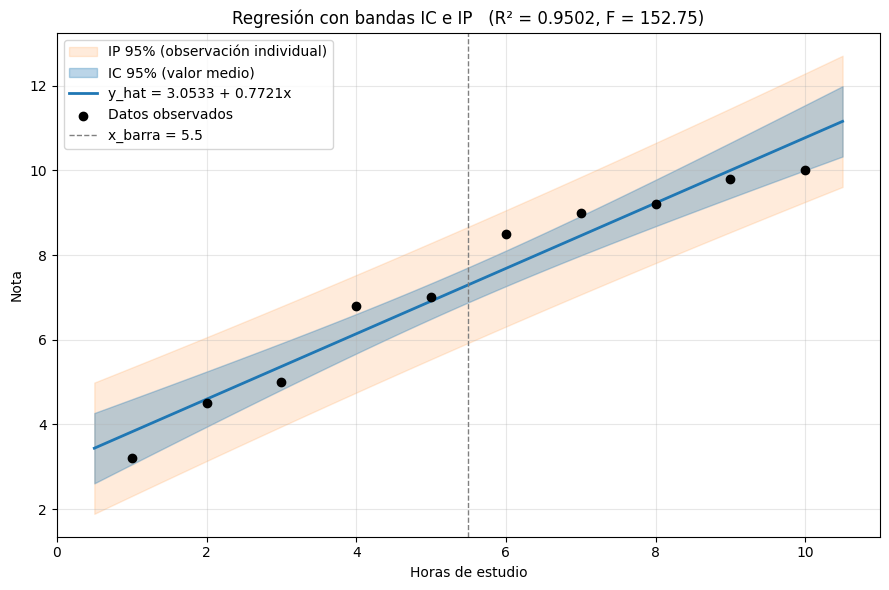

In [27]:
# Malla fina de X para dibujar bandas suaves (no solo en los 10 puntos observados).
x_malla = np.linspace(x.min() - 0.5, x.max() + 0.5, 200)
bandas = [intervalos(x0) for x0 in x_malla]

y_linea = np.array([b['y_hat'] for b in bandas])
ic_inf  = np.array([b['IC_inf'] for b in bandas])
ic_sup  = np.array([b['IC_sup'] for b in bandas])
ip_inf  = np.array([b['IP_inf'] for b in bandas])
ip_sup  = np.array([b['IP_sup'] for b in bandas])

fig, ax = plt.subplots(figsize=(9, 6))

# De atrás hacia adelante: banda IP (más ancha), banda IC, recta y datos.
ax.fill_between(x_malla, ip_inf, ip_sup, alpha=0.15, color='tab:orange',
                label='IP 95% (observación individual)')
ax.fill_between(x_malla, ic_inf, ic_sup, alpha=0.30, color='tab:blue',
                label='IC 95% (valor medio)')
ax.plot(x_malla, y_linea, color='tab:blue', lw=2,
        label=f'y_hat = {beta0:.4f} + {beta1:.4f}x')
ax.scatter(x, y, color='black', zorder=5, label='Datos observados')
ax.axvline(x_bar, ls='--', color='gray', lw=1, label=f'x_barra = {x_bar}')

ax.set_xlabel('Horas de estudio')
ax.set_ylabel('Nota')
ax.set_title(f'Regresión con bandas IC e IP   (R² = {R2:.4f}, F = {F_stat:.2f})')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

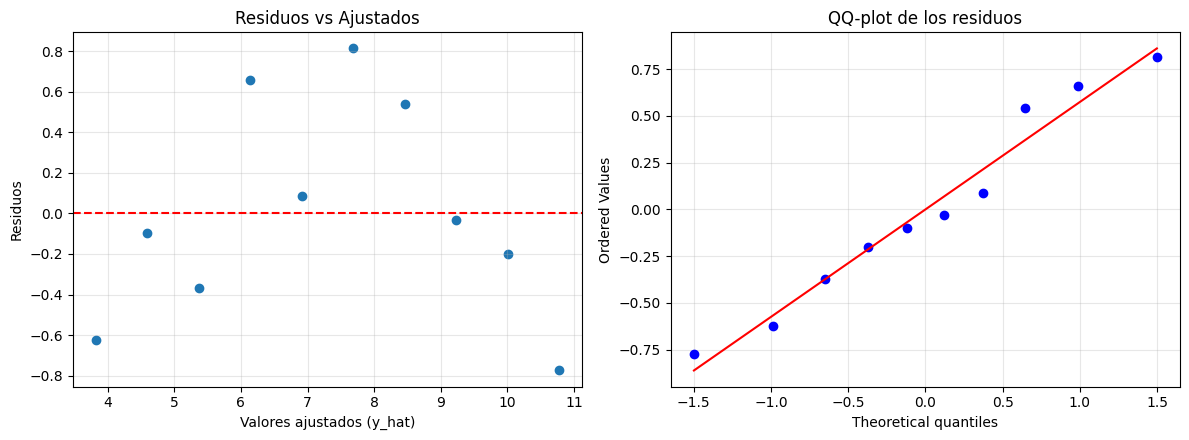

Suma de residuos = -1.33e-15  (debe ser ~0 en MCO con intercepto)


In [28]:
# Diagnóstico rápido de residuos: en un buen ajuste no deben mostrar patrón.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.scatter(y_hat, residuos, color='tab:blue')
ax1.axhline(0, color='red', ls='--')
ax1.set_xlabel('Valores ajustados (y_hat)')
ax1.set_ylabel('Residuos')
ax1.set_title('Residuos vs Ajustados')
ax1.grid(alpha=0.3)

# QQ-plot para checar el supuesto de normalidad de los errores.
stats.probplot(residuos, dist="norm", plot=ax2)
ax2.set_title('QQ-plot de los residuos')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Suma de residuos = {residuos.sum():.2e}  (debe ser ~0 en MCO con intercepto)")

---
## 10. Resumen de la sesión

Todo lo calculado, en un solo lugar.


In [29]:
# Resumen consolidado de todos los resultados del notebook.
print("=" * 62)
print("  RESUMEN — INFERENCIA EN REGRESIÓN LINEAL SIMPLE")
print("=" * 62)
print(f"Modelo estimado : y_hat = {beta0:.4f} + {beta1:.4f} * x")
print(f"n = {n}   p = {p}   df_error = {df_error}   alpha = {alpha}")
print("-" * 62)
print(f"ANOVA   SSR = {SSR:8.4f}   SSE = {SSE:8.4f}   SST = {SST:8.4f}")
print(f"        MSR = {MSR:8.4f}   MSE = {MSE:8.4f}   R²  = {R2:8.4f}")
print("-" * 62)
print(f"Prueba F: F = {F_stat:.4f} > F_c = {F_critico:.4f}  ->  modelo significativo")
print(f"          p-valor = {p_valor_F:.3e}")
print(f"Prueba t: t_beta1 = {t_beta1:.4f} > t_c = {t_critico:.4f}  ->  beta1 significativo")
print(f"          p-valor = {p_valor_t1:.3e}")
print(f"Relación: F = t²  ->  {F_stat:.4f} = {t_beta1**2:.4f}")
print("-" * 62)
print(f"IC 95% beta0 = [{IC_beta0[0]:.4f}, {IC_beta0[1]:.4f}]")
print(f"IC 95% beta1 = [{IC_beta1[0]:.4f}, {IC_beta1[1]:.4f}]  (no contiene 0)")
print(f"En X0 = 5:  IC media = [{ej['IC_inf']:.3f}, {ej['IC_sup']:.3f}]")
print(f"            IP indiv = [{ej['IP_inf']:.3f}, {ej['IP_sup']:.3f}]")
print("=" * 62)
print("Conclusión: hay evidencia suficiente para afirmar que las horas de")
print(f"estudio afectan significativamente la calificación (p < 0.001).")

  RESUMEN — INFERENCIA EN REGRESIÓN LINEAL SIMPLE
Modelo estimado : y_hat = 3.0533 + 0.7721 * x
n = 10   p = 1   df_error = 8   alpha = 0.05
--------------------------------------------------------------
ANOVA   SSR =  49.1841   SSE =   2.5759   SST =  51.7600
        MSR =  49.1841   MSE =   0.3220   R²  =   0.9502
--------------------------------------------------------------
Prueba F: F = 152.7529 > F_c = 5.3177  ->  modelo significativo
          p-valor = 1.712e-06
Prueba t: t_beta1 = 12.3593 > t_c = 2.3060  ->  beta1 significativo
          p-valor = 1.712e-06
Relación: F = t²  ->  152.7529 = 152.7529
--------------------------------------------------------------
IC 95% beta0 = [2.1594, 3.9472]
IC 95% beta1 = [0.6281, 0.9162]  (no contiene 0)
En X0 = 5:  IC media = [6.494, 7.334]
            IP indiv = [5.540, 8.288]
Conclusión: hay evidencia suficiente para afirmar que las horas de
estudio afectan significativamente la calificación (p < 0.001).


In [30]:
# CELDA OPCIONAL — verificación cruzada con statsmodels.
# No es necesaria para la tarea; solo confirma que los cálculos manuales coinciden
# con los de una librería estándar. Si no tienes statsmodels, la celda avisa y ya.
try:
    import statsmodels.api as sm
    modelo_sm = sm.OLS(y, sm.add_constant(x)).fit()
    print(modelo_sm.summary())
    print("\nComparación con nuestros cálculos manuales:")
    print(f"  beta:    {modelo_sm.params}  vs  [{beta0:.4f}, {beta1:.4f}]")
    print(f"  F:       {modelo_sm.fvalue:.4f}  vs  {F_stat:.4f}")
    print(f"  R²:      {modelo_sm.rsquared:.4f}  vs  {R2:.4f}")
except ImportError:
    print("statsmodels no está instalado — celda opcional omitida.")
    print("Si lo quieres:  pip install statsmodels")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     152.8
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           1.71e-06
Time:                        22:36:07   Log-Likelihood:                -7.4074
No. Observations:                  10   AIC:                             18.81
Df Residuals:                       8   BIC:                             19.42
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0533      0.388      7.877      0.0

---

### Nota sobre pequeñas diferencias con las diapositivas

En la presentación aparecen $SSR = 49.1814$ y $F = 152.7445$; aquí salen $SSR = 49.1841$ y
$F = 152.7529$. No es un error de ninguno de los dos: la diapositiva calculó las sumas de cuadrados
usando los coeficientes ya **redondeados** a 4 decimales ($\hat\beta_1 = 0.7721$), mientras que este
notebook arrastra la precisión completa. La diferencia es de rounding y no cambia ninguna conclusión.


In [32]:
from google.colab import files
from nbconvert import HTMLExporter
import nbformat

# Cargar el archivo .ipynb en el cuaderno
direccion_nombre ='/content/drive/MyDrive/Actividad_3.ipynb' # Reemplaza con el nombre de tu cuaderno

# Leer el archivo .ipynb

with open(direccion_nombre) as f:
     contenido = f.read()

# Convertir a HTML
leer_cuaderno = nbformat.reads(contenido, as_version=4)
html_exportar = HTMLExporter()

#html_exporter.exclude_input = False  # Excluye el código si es necesario
html_contenido, _ = html_exportar.from_notebook_node(leer_cuaderno)

# Guardar el archivo HTML

with open('/content/drive/MyDrive/Actividad_3.html', 'w') as f:
    f.write(html_contenido)

# Descargar el archivo HTML
files.download('/content/drive/MyDrive/Actividad_3.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>